In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import hashlib
import shutil
import pandas as pd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
mydrive = Path("/content/drive/MyDrive")

dataset_folders = []

for folder in mydrive.rglob("dataset"):
    if folder.is_dir():
        try:
            contents = os.listdir(folder)
            if "Healthy_Tomato" in contents and "Diseased_Tomato" in contents:
                dataset_folders.append(folder)
        except:
            pass

print("Dataset folders found:")

for i, folder in enumerate(dataset_folders):
    print(i, folder)

# Use the first dataset folder found
dataset_path = dataset_folders[0]
base_path = dataset_path.parent

healthy_path = dataset_path / "Healthy_Tomato"
diseased_path = dataset_path / "Diseased_Tomato"

print("\nUsing dataset path:")
print(dataset_path)

print("\nBase project path:")
print(base_path)

Dataset folders found:
0 /content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/dataset

Using dataset path:
/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/dataset

Base project path:
/content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project


In [ ]:
extensions = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]

def get_image_files(folder):
    image_files = []
    for ext in extensions:
        image_files.extend(list(folder.glob(ext)))
    return image_files

healthy_images = get_image_files(healthy_path)
diseased_images = get_image_files(diseased_path)

print("Original healthy images:", len(healthy_images))
print("Original diseased images:", len(diseased_images))
print("Total original images:", len(healthy_images) + len(diseased_images))

Original healthy images: 974
Original diseased images: 1012
Total original images: 1986


In [ ]:
cleaned_path = base_path / "cleaned_dataset"

classes = ["Healthy_Tomato", "Diseased_Tomato"]

for class_name in classes:
    (cleaned_path / class_name).mkdir(parents=True, exist_ok=True)

def file_hash(file_path):
    with open(file_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

records = []
seen_hashes = set()

for class_name in classes:
    input_folder = dataset_path / class_name
    output_folder = cleaned_path / class_name

    image_files = get_image_files(input_folder)

    print("Cleaning folder:", class_name)
    print("Images found:", len(image_files))

    count = 1

    for image_file in image_files:
        status = "Kept"
        reason = ""

        image = cv2.imread(str(image_file))

        if image is None:
            status = "Removed"
            reason = "Corrupted or unreadable image"

        else:
            img_hash = file_hash(image_file)

            if img_hash in seen_hashes:
                status = "Removed"
                reason = "Duplicate image"

            else:
                seen_hashes.add(img_hash)

                if class_name == "Healthy_Tomato":
                    new_name = f"healthy_tomato_{count:03d}.jpg"
                else:
                    new_name = f"diseased_tomato_{count:03d}.jpg"

                save_path = output_folder / new_name
                cv2.imwrite(str(save_path), image)

                reason = "Clean image saved"
                count += 1

        records.append({
            "Class": class_name,
            "Original_File": image_file.name,
            "Status": status,
            "Reason": reason
        })

    print(class_name, "cleaning completed.")
    print()

report_df = pd.DataFrame(records)
report_path = cleaned_path / "dataset_cleaning_report.csv"
report_df.to_csv(report_path, index=False)

print("Dataset cleaning completed.")
print("Cleaning report saved at:", report_path)

Cleaning folder: Healthy_Tomato
Images found: 974
Healthy_Tomato cleaning completed.

Cleaning folder: Diseased_Tomato
Images found: 1012
Diseased_Tomato cleaning completed.

Dataset cleaning completed.
Cleaning report saved at: /content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/cleaned_dataset/dataset_cleaning_report.csv


In [ ]:
healthy_cleaned_path = cleaned_path / "Healthy_Tomato"
diseased_cleaned_path = cleaned_path / "Diseased_Tomato"

healthy_cleaned = get_image_files(healthy_cleaned_path)
diseased_cleaned = get_image_files(diseased_cleaned_path)

print("Cleaned healthy images:", len(healthy_cleaned))
print("Cleaned diseased images:", len(diseased_cleaned))
print("Total cleaned images:", len(healthy_cleaned) + len(diseased_cleaned))

Cleaned healthy images: 971
Cleaned diseased images: 1012
Total cleaned images: 1983


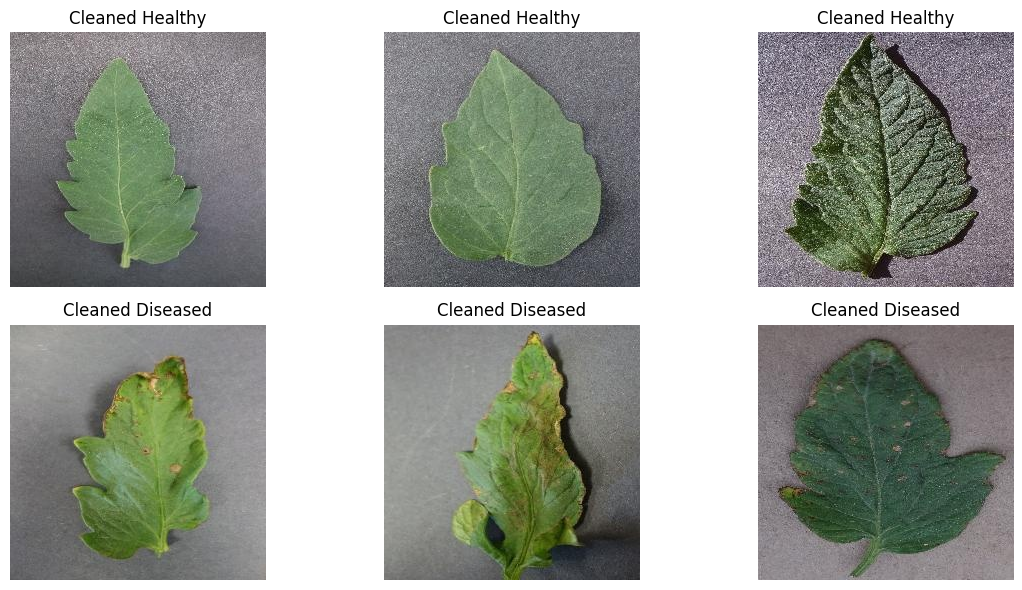

In [ ]:
plt.figure(figsize=(12, 6))

for i, img_path in enumerate(healthy_cleaned[:3]):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title("Cleaned Healthy")
    plt.axis("off")

for i, img_path in enumerate(diseased_cleaned[:3]):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 4)
    plt.imshow(img)
    plt.title("Cleaned Diseased")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
preprocessed_path = base_path / "preprocessed"

for class_name in classes:
    input_folder = cleaned_path / class_name
    output_folder = preprocessed_path / class_name

    output_folder.mkdir(parents=True, exist_ok=True)

    image_files = get_image_files(input_folder)

    print("Preprocessing folder:", class_name)
    print("Images found:", len(image_files))

    for image_file in image_files:
        image = cv2.imread(str(image_file))

        if image is None:
            print("Skipped bad image:", image_file.name)
            continue

        resized = cv2.resize(image, (500, 500))
        gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
        contrast = cv2.equalizeHist(gray)
        normalized = cv2.normalize(contrast, None, 0, 255, cv2.NORM_MINMAX)

        save_name = "preprocessed_" + image_file.stem + ".jpg"
        save_path = output_folder / save_name

        cv2.imwrite(str(save_path), normalized)

    print(class_name, "preprocessing completed.")
    print()

print("All images preprocessed successfully.")

Preprocessing folder: Healthy_Tomato
Images found: 971
Healthy_Tomato preprocessing completed.

Preprocessing folder: Diseased_Tomato
Images found: 1012
Diseased_Tomato preprocessing completed.

All images preprocessed successfully.


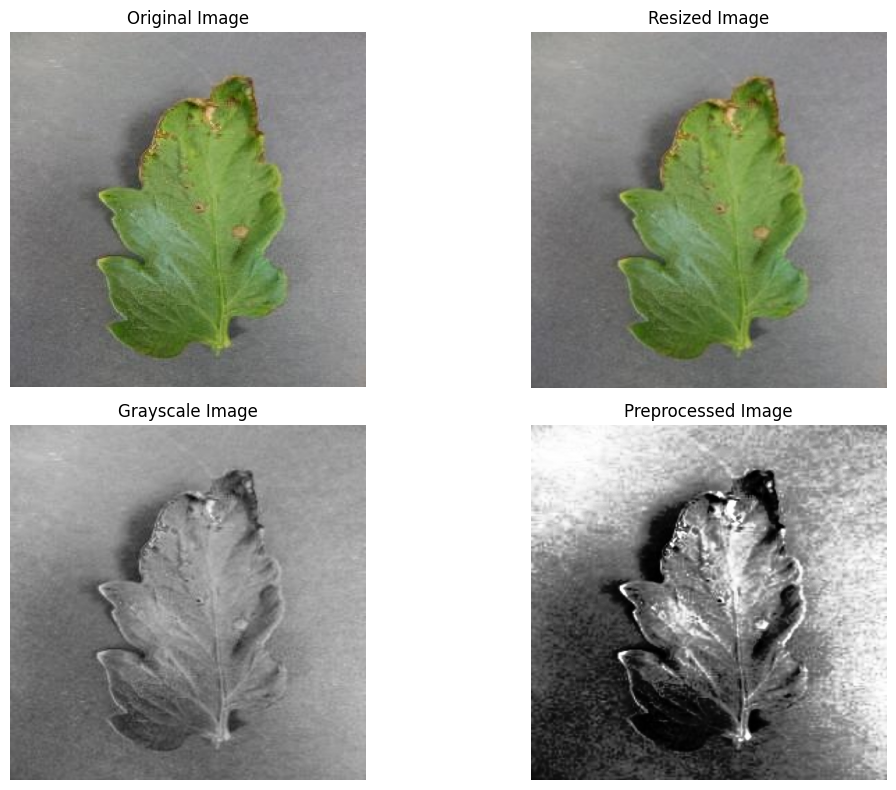

In [ ]:
sample_original_path = diseased_cleaned[0]

sample_original = cv2.imread(str(sample_original_path))
sample_original_rgb = cv2.cvtColor(sample_original, cv2.COLOR_BGR2RGB)

sample_resized = cv2.resize(sample_original, (500, 500))
sample_resized_rgb = cv2.cvtColor(sample_resized, cv2.COLOR_BGR2RGB)

sample_gray = cv2.cvtColor(sample_resized, cv2.COLOR_BGR2GRAY)
sample_contrast = cv2.equalizeHist(sample_gray)
sample_normalized = cv2.normalize(sample_contrast, None, 0, 255, cv2.NORM_MINMAX)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(sample_original_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(sample_resized_rgb)
plt.title("Resized Image")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(sample_gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(sample_normalized, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
filtered_path = base_path / "filtered"

for class_name in classes:
    input_folder = preprocessed_path / class_name
    output_folder = filtered_path / class_name

    output_folder.mkdir(parents=True, exist_ok=True)

    image_files = get_image_files(input_folder)

    print("Filtering folder:", class_name)
    print("Images found:", len(image_files))

    for image_file in image_files:
        image = cv2.imread(str(image_file), cv2.IMREAD_GRAYSCALE)

        if image is None:
            print("Skipped bad image:", image_file.name)
            continue

        gaussian = cv2.GaussianBlur(image, (5, 5), 0)

        save_name = "filtered_" + image_file.stem + ".jpg"
        save_path = output_folder / save_name

        cv2.imwrite(str(save_path), gaussian)

    print(class_name, "filtering completed.")
    print()

print("All images filtered successfully.")

Filtering folder: Healthy_Tomato
Images found: 971
Healthy_Tomato filtering completed.

Filtering folder: Diseased_Tomato
Images found: 1012
Diseased_Tomato filtering completed.

All images filtered successfully.


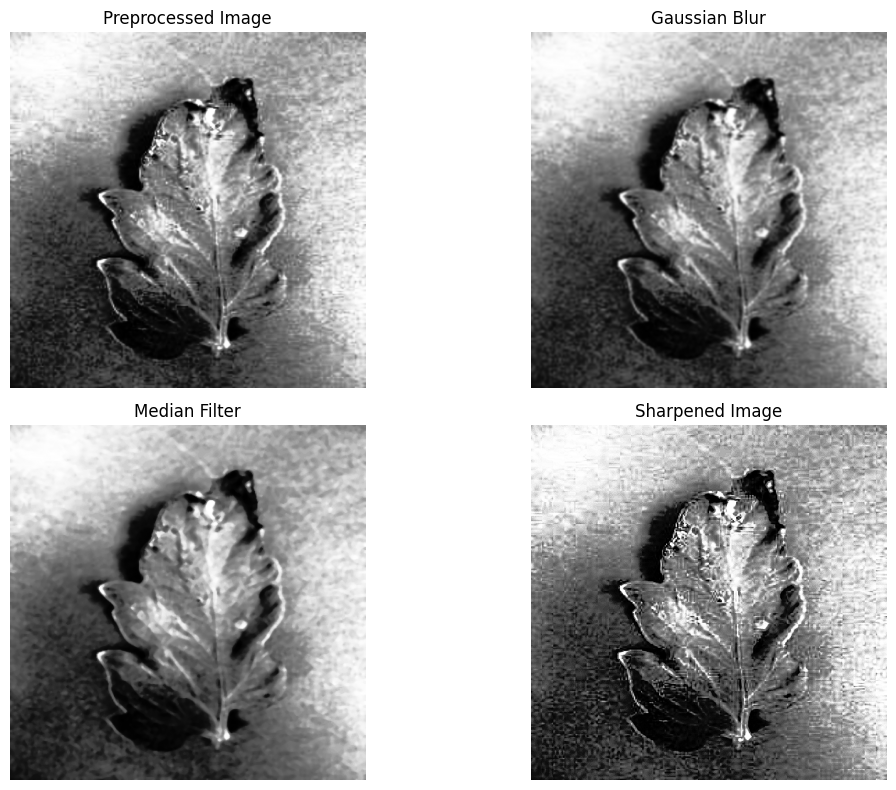

In [ ]:
sample_image = sample_normalized

gaussian = cv2.GaussianBlur(sample_image, (5, 5), 0)
median = cv2.medianBlur(sample_image, 5)

sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharpened = cv2.filter2D(sample_image, -1, sharpen_kernel)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(sample_image, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(gaussian, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(median, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(sharpened, cmap="gray")
plt.title("Sharpened Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
segmented_path = base_path / "segmented" / "Diseased_Tomato"
edges_path = base_path / "edges" / "Diseased_Tomato"
final_output_path = base_path / "final_output" / "Diseased_Tomato"

segmented_path.mkdir(parents=True, exist_ok=True)
edges_path.mkdir(parents=True, exist_ok=True)
final_output_path.mkdir(parents=True, exist_ok=True)

input_folder = filtered_path / "Diseased_Tomato"
image_files = get_image_files(input_folder)

print("Filtered diseased images found:", len(image_files))

for image_file in image_files:
    image = cv2.imread(str(image_file), cv2.IMREAD_GRAYSCALE)

    if image is None:
        print("Skipped:", image_file.name)
        continue

    _, mask = cv2.threshold(
        image,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = np.ones((5, 5), np.uint8)

    clean_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel)

    edges = cv2.Canny(clean_mask, 50, 150)

    contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    output = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    for contour in contours:
        area = cv2.contourArea(contour)

        if area > 100:
            cv2.drawContours(output, [contour], -1, (0, 0, 255), 2)

            x, y, w, h = cv2.boundingRect(contour)
            cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)

    cv2.imwrite(str(segmented_path / ("segmented_" + image_file.stem + ".jpg")), clean_mask)
    cv2.imwrite(str(edges_path / ("edges_" + image_file.stem + ".jpg")), edges)
    cv2.imwrite(str(final_output_path / ("final_" + image_file.stem + ".jpg")), output)

print("Segmentation, edge detection, and final outputs completed.")

Filtered diseased images found: 1012
Segmentation, edge detection, and final outputs completed.


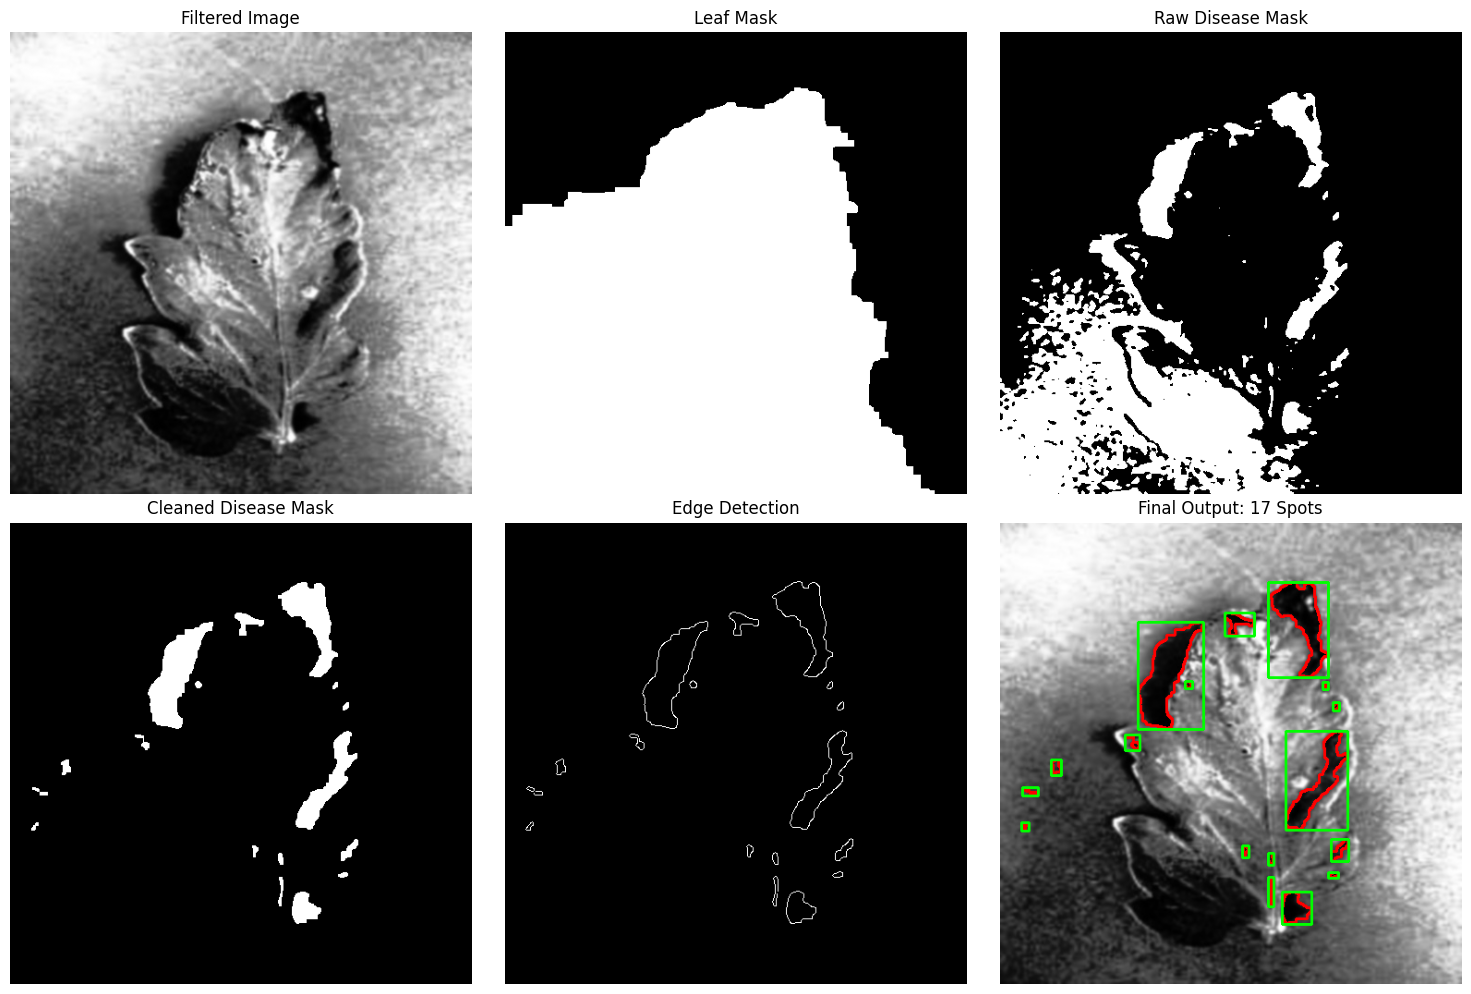

In [ ]:
# Improved segmentation example

filtered_diseased_images = get_image_files(filtered_path / "Diseased_Tomato")

sample_filtered_path = filtered_diseased_images[0]
image = cv2.imread(str(sample_filtered_path), cv2.IMREAD_GRAYSCALE)

# Smooth image a little
blur = cv2.GaussianBlur(image, (5, 5), 0)

# ----------------------------
# STEP 1: Detect the leaf mask
# ----------------------------
_, leaf_mask = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

kernel_leaf = np.ones((7, 7), np.uint8)
leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, kernel_leaf, iterations=2)
leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_OPEN, kernel_leaf, iterations=1)

# Keep only the largest contour = the leaf
contours_leaf, _ = cv2.findContours(leaf_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

largest_leaf_mask = np.zeros_like(leaf_mask)

if len(contours_leaf) > 0:
    largest_contour = max(contours_leaf, key=cv2.contourArea)
    cv2.drawContours(largest_leaf_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

# -----------------------------------------
# STEP 2: Detect dark disease spots in leaf
# -----------------------------------------
leaf_pixels = image[largest_leaf_mask == 255]

# Use a threshold based only on leaf pixels
spot_threshold = int(np.mean(leaf_pixels) - 0.5 * np.std(leaf_pixels))

# Create raw spot mask
spot_mask = np.zeros_like(image)
spot_mask[(image < spot_threshold) & (largest_leaf_mask == 255)] = 255

# -------------------------
# STEP 3: Clean spot mask
# -------------------------
kernel_spot = np.ones((3, 3), np.uint8)
clean_mask = cv2.morphologyEx(spot_mask, cv2.MORPH_OPEN, kernel_spot, iterations=1)
clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel_spot, iterations=2)

# --------------------------------
# STEP 4: Keep only valid spot size
# --------------------------------
final_spot_mask = np.zeros_like(clean_mask)

contours_spot, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

leaf_area = cv2.countNonZero(largest_leaf_mask)

spot_count = 0
valid_contours = []

for contour in contours_spot:
    area = cv2.contourArea(contour)

    # Keep only medium-size spots
    if 20 < area < (0.15 * leaf_area):
        cv2.drawContours(final_spot_mask, [contour], -1, 255, thickness=cv2.FILLED)
        valid_contours.append(contour)
        spot_count += 1

# -------------------------
# STEP 5: Edge detection
# -------------------------
edges = cv2.Canny(final_spot_mask, 50, 150)

# -------------------------
# STEP 6: Final output
# -------------------------
output = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

for contour in valid_contours:
    cv2.drawContours(output, [contour], -1, (0, 0, 255), 2)

    x, y, w, h = cv2.boundingRect(contour)
    cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)

output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

# -------------------------
# STEP 7: Show better figure
# -------------------------
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Filtered Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(largest_leaf_mask, cmap="gray")
plt.title("Leaf Mask")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(spot_mask, cmap="gray")
plt.title("Raw Disease Mask")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(final_spot_mask, cmap="gray")
plt.title("Cleaned Disease Mask")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(edges, cmap="gray")
plt.title("Edge Detection")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(output_rgb)
plt.title(f"Final Output: {spot_count} Spots")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("FINAL PROJECT CHECK")
print("-------------------")

print("Original healthy:", len(get_image_files(dataset_path / "Healthy_Tomato")))
print("Original diseased:", len(get_image_files(dataset_path / "Diseased_Tomato")))
print()

print("Cleaned healthy:", len(get_image_files(cleaned_path / "Healthy_Tomato")))
print("Cleaned diseased:", len(get_image_files(cleaned_path / "Diseased_Tomato")))
print()

print("Preprocessed healthy:", len(get_image_files(preprocessed_path / "Healthy_Tomato")))
print("Preprocessed diseased:", len(get_image_files(preprocessed_path / "Diseased_Tomato")))
print()

print("Filtered healthy:", len(get_image_files(filtered_path / "Healthy_Tomato")))
print("Filtered diseased:", len(get_image_files(filtered_path / "Diseased_Tomato")))
print()

print("Segmented diseased:", len(get_image_files(segmented_path)))
print("Edges diseased:", len(get_image_files(edges_path)))
print("Final output diseased:", len(get_image_files(final_output_path)))

FINAL PROJECT CHECK
-------------------
Original healthy: 1000
Original diseased: 1012

Cleaned healthy: 971
Cleaned diseased: 1012

Preprocessed healthy: 971
Preprocessed diseased: 1012

Filtered healthy: 971
Filtered diseased: 1012

Segmented diseased: 1012
Edges diseased: 1012
Final output diseased: 1012


In [ ]:
screenshots_path = base_path / "screenshots"
screenshots_path.mkdir(parents=True, exist_ok=True)

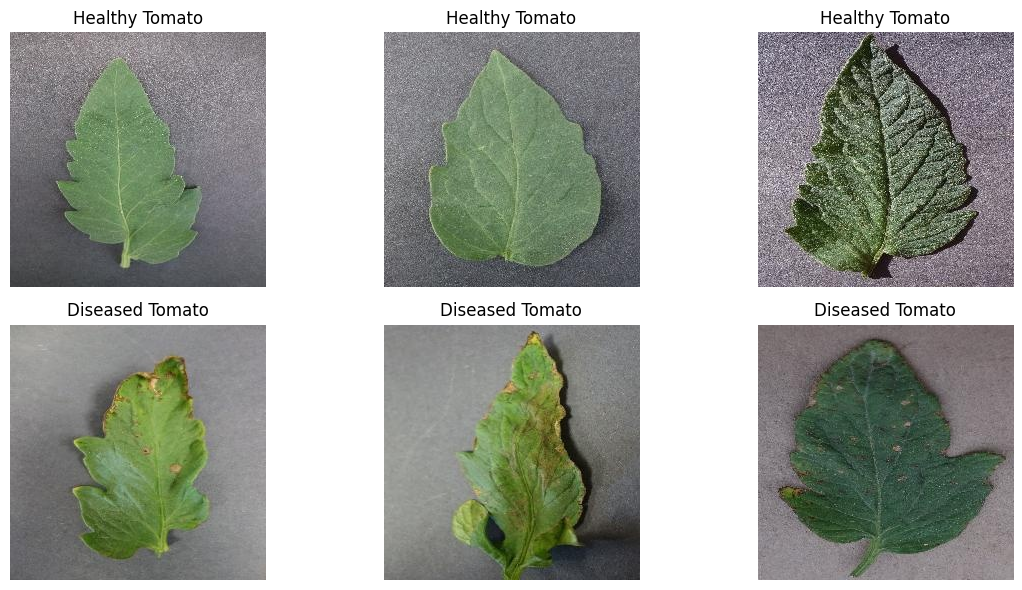

In [ ]:
plt.figure(figsize=(12, 6))

for i, img_path in enumerate(healthy_cleaned[:3]):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title("Healthy Tomato")
    plt.axis("off")

for i, img_path in enumerate(diseased_cleaned[:3]):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 4)
    plt.imshow(img)
    plt.title("Diseased Tomato")
    plt.axis("off")

plt.tight_layout()
plt.savefig(screenshots_path / "00_dataset_samples.png", dpi=300, bbox_inches="tight")
plt.show()

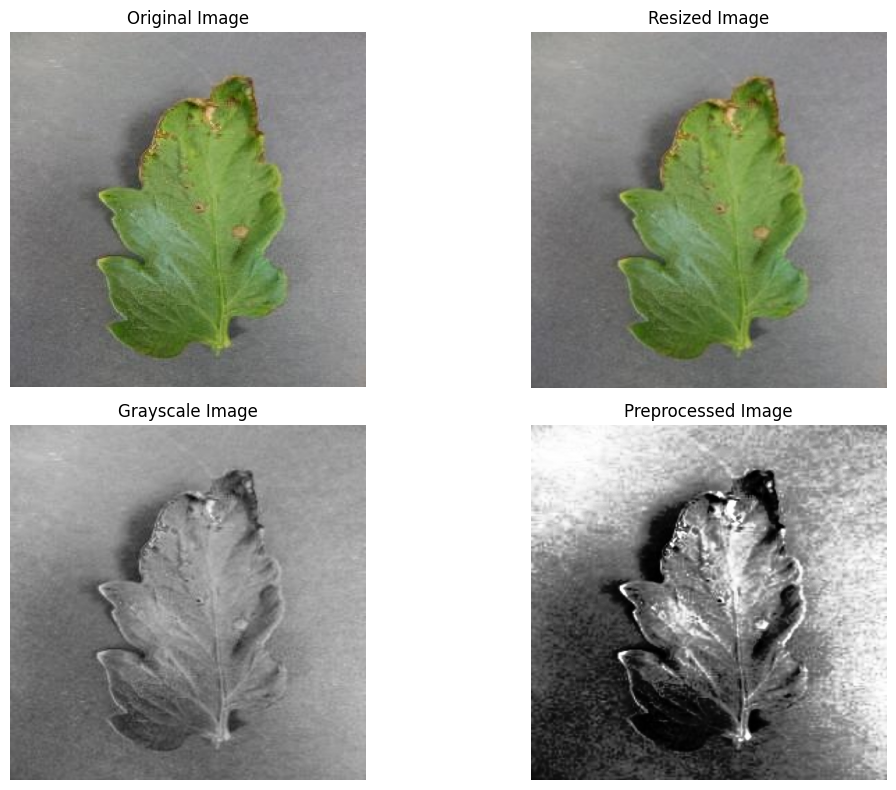

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(sample_original_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(sample_resized_rgb)
plt.title("Resized Image")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(sample_gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(sample_normalized, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")

plt.tight_layout()
plt.savefig(screenshots_path / "01_preprocessing_result.png", dpi=300, bbox_inches="tight")
plt.show()

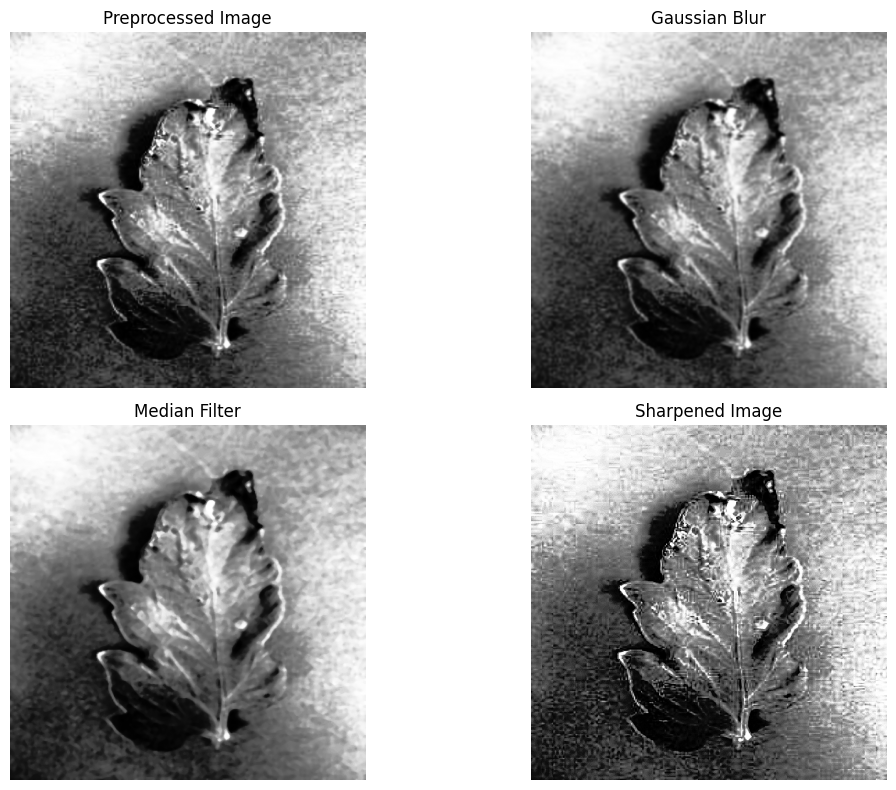

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(sample_image, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(gaussian, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(median, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(sharpened, cmap="gray")
plt.title("Sharpened Image")
plt.axis("off")

plt.tight_layout()
plt.savefig(screenshots_path / "02_filtering_result.png", dpi=300, bbox_inches="tight")
plt.show()

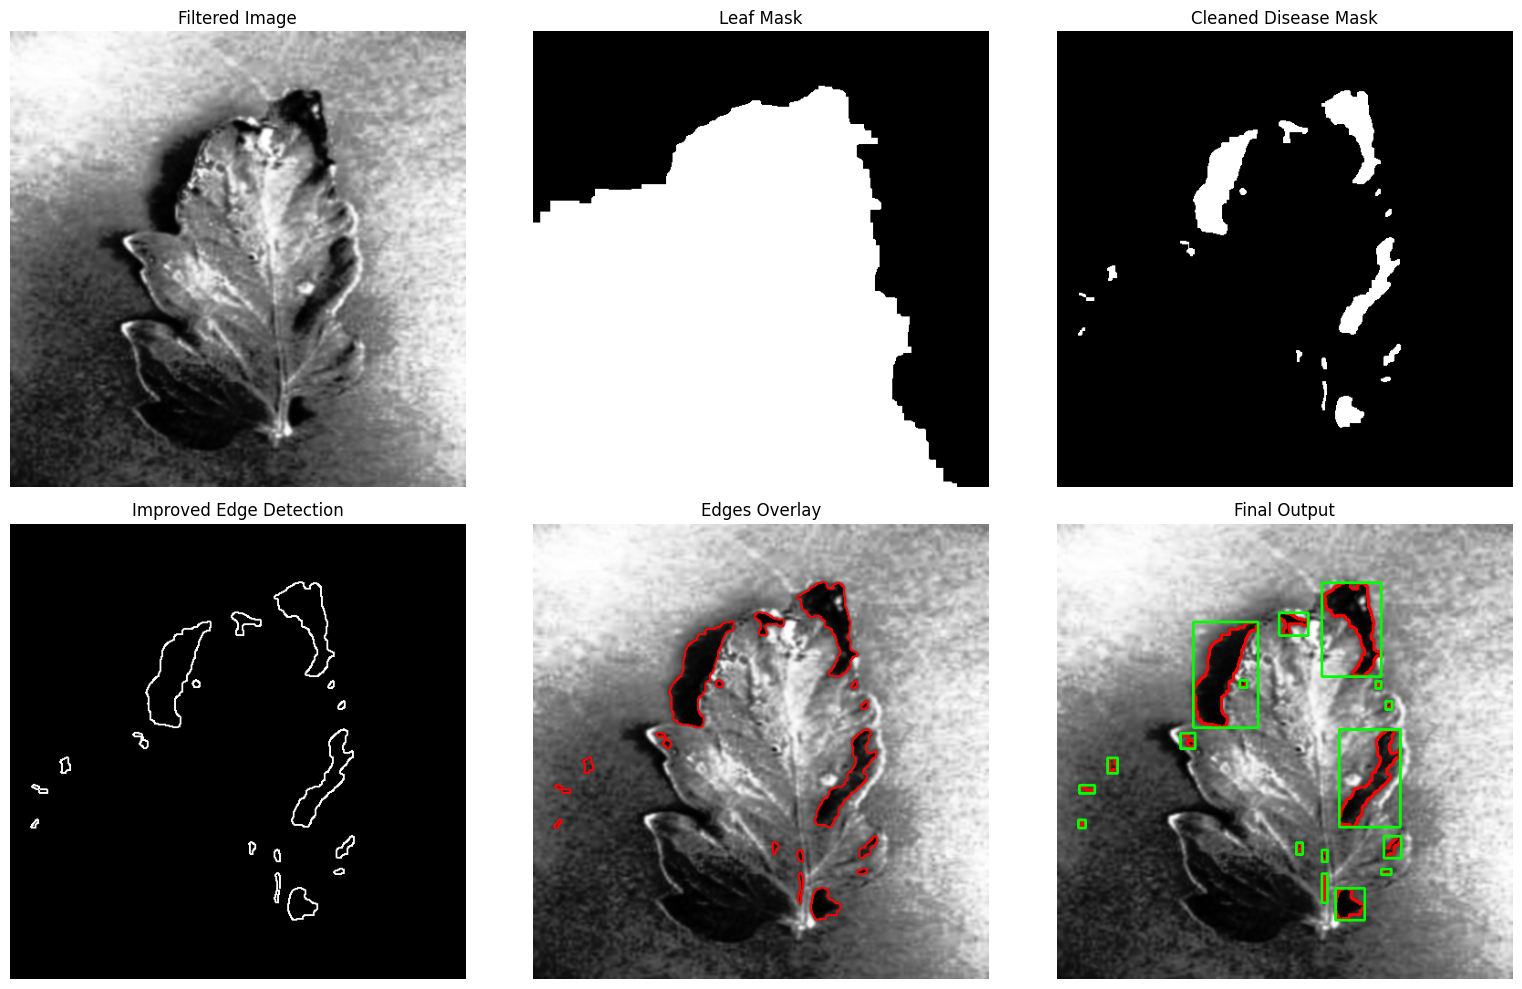

Saved improved screenshot at: /content/drive/MyDrive/Tomato_Disease_Project/Tomato_Disease_Project/screenshots/03_segmentation_edge_result.png


In [ ]:
screenshots_path = base_path / "screenshots"
screenshots_path.mkdir(parents=True, exist_ok=True)

edge_kernel = np.ones((2, 2), np.uint8)
thick_edges = cv2.dilate(edges, edge_kernel, iterations=1)

edge_overlay = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
edge_overlay[thick_edges > 0] = [0, 0, 255]
edge_overlay_rgb = cv2.cvtColor(edge_overlay, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Filtered Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(largest_leaf_mask, cmap="gray")
plt.title("Leaf Mask")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(final_spot_mask, cmap="gray")
plt.title("Cleaned Disease Mask")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(thick_edges, cmap="gray")
plt.title("Improved Edge Detection")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(edge_overlay_rgb)
plt.title("Edges Overlay")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(output_rgb)
plt.title("Final Output")
plt.axis("off")

plt.tight_layout()

save_path = screenshots_path / "03_segmentation_edge_result.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved improved screenshot at:", save_path)